# **DESPLIEGUE DEL MODELO CON INTERFAZ GRÁFICA (PUNTO D)**

**Práctica 3 · Minería de Datos en Python · California Housing Prices**
Daniel Cardona González · Juan José Tamayo Ospina

- Cargamos el modelo final (XGBoost hiperparametrizado) desde `modelo-xgb-final.pkl`
- Preparamos los datos nuevos: razones por hogar y dummies (sin escalar, XGBoost no lo necesita)
- Probamos el modelo con datos reales
- Desplegamos la aplicación con Streamlit

**Archivos necesarios en la misma carpeta:** `modelo-xgb-final.pkl` (sección 7 del notebook de modelos) y `housing.csv`. En Google Colab se suben con el panel de archivos de la izquierda.

**Corrección frente al despliegue del parcial:** el modelo del parcial se entrenó con datos sin escalar, pero en el despliegue se le pasaban datos normalizados entre 0 y 1, así que sus predicciones no tenían sentido. Ahora los datos se ingresan en su escala real y se preparan igual que en el entrenamiento.

In [1]:
!pip install -q streamlit

# **1. Cargamos el modelo**

In [2]:
import pickle
import pandas as pd

filename = 'modelo-xgb-final.pkl'
modelo, variables, metricas = pickle.load(open(filename, 'rb'))

print(modelo)
print('\nVariables:', variables)
print('\nMétricas en el 30% de prueba:', {k: round(v, 3) for k, v in metricas.items()})

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

Variables: ['longitude', 'latitude', 'housing_median_age', 'median_income', 'population_per_household', 'rooms_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

Métricas en el 30% de prueba: {'RMSE': np.flo

# **2. Preparación de los datos nuevos**

Los datos llegan en su escala original. Esta función calcula las razones por hogar, crea las dummies de `ocean_proximity` (ISLAND se trata como NEAR OCEAN, igual que en el entrenamiento) y ordena las columnas como las espera el modelo. La aplicación usa exactamente la misma función.

In [3]:
def preparar_datos(datos, variables):
    X = datos[['longitude', 'latitude', 'housing_median_age', 'median_income']].astype(float)
    X['population_per_household'] = datos['population'] / datos['households']
    X['rooms_per_household'] = datos['total_rooms'] / datos['households']
    oceano = datos['ocean_proximity'].replace('ISLAND', 'NEAR OCEAN')
    for categoria in ['INLAND', 'NEAR BAY', 'NEAR OCEAN']:
        X['ocean_proximity_' + categoria] = (oceano == categoria).astype(int)
    return X[variables]

# **3. Predicciones**

Se toman 5 distritos reales de la base y se comparan las predicciones con su valor real. Estos distritos hicieron parte del entrenamiento final (el modelo se reentrenó con el 100% de los datos), así que la prueba solo verifica que el despliegue funciona. El desempeño con datos nuevos se midió en el notebook de modelos: R² de 0,855 y MAE de unos 28.000 dólares.

In [4]:
data = pd.read_csv('housing.csv')
nuevos_datos = data.sample(5, random_state=7).drop(columns=['median_house_value', 'total_bedrooms'])
nuevos_datos

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
4648,-118.31,34.06,31.0,2827.0,3107.0,993.0,2.0278,<1H OCEAN
8740,-118.31,33.81,30.0,1773.0,905.0,352.0,4.3056,<1H OCEAN
162,-122.24,37.81,52.0,2513.0,1048.0,518.0,3.6750,NEAR BAY
15735,-122.43,37.78,26.0,3587.0,1821.0,936.0,2.6392,NEAR BAY
18380,-121.86,37.21,23.0,2552.0,916.0,316.0,9.1974,<1H OCEAN


In [5]:
X_nuevos = preparar_datos(nuevos_datos, variables)
Y_pred = modelo.predict(X_nuevos)

resultado = nuevos_datos[['longitude', 'latitude', 'median_income', 'ocean_proximity']].copy()
resultado['valor_real'] = data.loc[nuevos_datos.index, 'median_house_value']
resultado['prediccion'] = Y_pred.round(0)
resultado

,longitude,latitude,median_income,ocean_proximity,valor_real,prediccion
4648,-118.31,34.06,2.0278,<1H OCEAN,360000.0,314628.0
8740,-118.31,33.81,4.3056,<1H OCEAN,336000.0,296051.0
162,-122.24,37.81,3.6750,NEAR BAY,269900.0,281302.0
15735,-122.43,37.78,2.6392,NEAR BAY,287500.0,302163.0
18380,-121.86,37.21,9.1974,<1H OCEAN,500001.0,472146.0


# **4. Aplicación Streamlit**

La aplicación tiene una barra lateral para ingresar los datos del distrito y cuatro pestañas: mapa, análisis, información del modelo y predicción por lotes (CSV). La estimación se actualiza al mover cualquier control.

In [6]:
%%writefile app.py
"""Estimador del valor de vivienda en California
Práctica 3 · Minería de Datos en Python · UPB
Daniel Cardona González · Juan José Tamayo Ospina

Ejecutar con:  streamlit run app.py

Archivos necesarios en la misma carpeta:
  modelo-xgb-final.pkl  (sección 7 del notebook de modelos)
  housing.csv
"""
import pickle

import altair as alt
import numpy as np
import pandas as pd
import pydeck as pdk
import streamlit as st

# Columnas que el usuario ingresa, en su escala original (sin normalizar)
COLUMNAS_ENTRADA = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                    'population', 'households', 'median_income', 'ocean_proximity']
CATEGORIAS_OCEANO = ['<1H OCEAN', 'INLAND', 'NEAR BAY', 'NEAR OCEAN']


def preparar_datos(datos, variables):
    """Convierte los datos crudos en las variables del modelo: razones por hogar,
    dummies de ocean_proximity (ISLAND se trata como NEAR OCEAN) y mismo orden de columnas."""
    faltantes = [c for c in COLUMNAS_ENTRADA if c not in datos.columns]
    if faltantes:
        raise ValueError(f'Faltan columnas: {faltantes}')
    X = datos[['longitude', 'latitude', 'housing_median_age', 'median_income']].astype(float)
    X['population_per_household'] = datos['population'] / datos['households']
    X['rooms_per_household'] = datos['total_rooms'] / datos['households']
    oceano = datos['ocean_proximity'].replace('ISLAND', 'NEAR OCEAN')
    for categoria in ['INLAND', 'NEAR BAY', 'NEAR OCEAN']:
        X['ocean_proximity_' + categoria] = (oceano == categoria).astype(int)
    return X[variables]


st.set_page_config(page_title='Valor de vivienda en California', page_icon=':material/home:', layout='wide')

AZUL, AZUL_OSCURO, NARANJA = '#2a78d6', '#0d366b', '#eb6834'
RAMPA_AZUL = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']

st.markdown("""
<style>
.block-container {padding-top: 2rem;}
.hero {background: linear-gradient(120deg, #0d366b 0%, #1c5cab 55%, #3987e5 100%);
       border-radius: 18px; padding: 26px 32px; margin-bottom: 1.2rem; color: #ffffff;}
.hero h1 {color: #ffffff; font-size: 2.1rem; margin: 0; padding: 0; line-height: 1.2;}
.hero p {color: #cde2fb; margin: .45rem 0 0; font-size: 1rem;}
.hero .chips {margin-top: .9rem;}
.hero .chip {display: inline-block; background: rgba(255,255,255,.14); border: 1px solid rgba(255,255,255,.25);
             border-radius: 999px; padding: 3px 12px; margin: 0 6px 6px 0; font-size: .82rem; color: #ffffff;}
.resultado {border: 1px solid rgba(42,120,214,.35); background: rgba(42,120,214,.07);
            border-radius: 16px; padding: 20px 26px; min-height: 148px;}
.resultado .etiqueta {font-size: .9rem; opacity: .75; margin: 0;}
.resultado .valor {font-size: 2.9rem; font-weight: 700; line-height: 1.15; margin: .2rem 0;}
.resultado .rango {font-size: .92rem; opacity: .8; margin: 0;}
.tarjeta {border: 1px solid rgba(128,128,128,.25); border-radius: 16px; padding: 16px 20px; min-height: 148px;}
.tarjeta .etiqueta {font-size: .85rem; opacity: .7; margin: 0;}
.tarjeta .valor {font-size: 1.7rem; font-weight: 650; margin: .15rem 0;}
.tarjeta .nota {font-size: .82rem; opacity: .7; margin: 0;}
</style>
""", unsafe_allow_html=True)


EJE_MILES = "'$' + format(datum.value / 1000, ',.0f') + 'k'"

NOMBRES = {
    'latitude': 'Latitud', 'longitude': 'Longitud', 'median_income': 'Ingreso mediano',
    'population_per_household': 'Personas por vivienda', 'rooms_per_household': 'Cuartos por vivienda',
    'housing_median_age': 'Antigüedad', 'ocean_proximity_INLAND': 'Océano: INLAND',
    'ocean_proximity_NEAR BAY': 'Océano: NEAR BAY', 'ocean_proximity_NEAR OCEAN': 'Océano: NEAR OCEAN',
}


def usd(v):
    return '$ ' + f'{v:,.0f}'.replace(',', '.')


def decimal(v, n=1):
    return f'{v:,.{n}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')


# ---------------------------------------------------------------- Datos y modelo
@st.cache_resource
def cargar_modelo():
    modelo, variables, metricas = pickle.load(open('modelo-xgb-final.pkl', 'rb'))
    return modelo, variables, metricas


@st.cache_data
def cargar_datos():
    datos = pd.read_csv('housing.csv')
    datos['ocean_proximity'] = datos['ocean_proximity'].replace('ISLAND', 'NEAR OCEAN')
    return datos


modelo, variables, metricas = cargar_modelo()
datos = cargar_datos()
mae = metricas['MAE']


def predecir(datos_crudos):
    return modelo.predict(preparar_datos(datos_crudos, variables))


def vecinos_cercanos(lat, lon, k=10):
    # Distancia aproximada en km (suficiente para distancias cortas)
    dlat = (datos['latitude'] - lat) * 111.0
    dlon = (datos['longitude'] - lon) * 111.0 * np.cos(np.radians(lat))
    dist = np.sqrt(dlat ** 2 + dlon ** 2)
    idx = dist.nsmallest(k).index
    return datos.loc[idx].assign(distancia_km=dist[idx])


# ---------------------------------------------------------------- Barra lateral: entradas
CIUDADES = {
    'Los Ángeles': (34.05, -118.24),
    'San Francisco': (37.77, -122.42),
    'San Diego': (32.72, -117.16),
    'San José': (37.34, -121.89),
    'Oakland': (37.80, -122.27),
    'Sacramento': (38.58, -121.49),
    'Fresno': (36.74, -119.79),
    'Bakersfield': (35.37, -119.02),
}
if 'lat' not in st.session_state:
    st.session_state.lat, st.session_state.lon = CIUDADES['Los Ángeles']


def control(etiqueta, minimo, maximo, inicial, paso, clave, formato):
    """Slider y caja numérica sincronizados: el valor se puede mover o escribir con el teclado."""
    if clave not in st.session_state:
        st.session_state[clave] = inicial
    st.session_state[clave + '_slider'] = st.session_state[clave]
    st.session_state[clave + '_caja'] = st.session_state[clave]

    def desde_slider():
        st.session_state[clave] = st.session_state[clave + '_slider']

    def desde_caja():
        st.session_state[clave] = st.session_state[clave + '_caja']

    c1, c2 = st.columns([2, 1], vertical_alignment='bottom')
    c1.slider(etiqueta, minimo, maximo, step=paso, key=clave + '_slider', on_change=desde_slider)
    c2.number_input(etiqueta, minimo, maximo, step=paso, format=formato, key=clave + '_caja',
                    on_change=desde_caja, label_visibility='collapsed')
    return st.session_state[clave]


def aplicar_ciudad():
    ciudad = st.session_state.ciudad
    if ciudad in CIUDADES:
        st.session_state.lat, st.session_state.lon = CIUDADES[ciudad]


with st.sidebar:
    st.header('Datos del distrito')

    st.subheader('Ubicación', divider='blue')
    st.selectbox('Ciudad de referencia', list(CIUDADES) + ['Personalizada'], key='ciudad', on_change=aplicar_ciudad)
    control('Latitud', 32.5, 42.0, 34.05, 0.01, 'lat', '%.2f')
    control('Longitud', -124.4, -114.3, -118.24, 0.01, 'lon', '%.2f')

    vecinos = vecinos_cercanos(st.session_state.lat, st.session_state.lon)
    oceano_sugerido = vecinos['ocean_proximity'].mode().iloc[0]
    auto_oceano = st.toggle('Detectar la proximidad al océano según los distritos vecinos', value=True)
    if auto_oceano:
        oceano = oceano_sugerido
        st.caption(f'Proximidad detectada: **{oceano}**')
    else:
        oceano = st.selectbox('Proximidad al océano', CATEGORIAS_OCEANO, index=CATEGORIAS_OCEANO.index(oceano_sugerido))

    st.subheader('Población y viviendas', divider='blue')
    ingreso = control('Ingreso mediano (decenas de miles de USD)', 0.5, 15.0, 3.5, 0.01, 'ingreso', '%.2f')
    st.caption(f'Equivale a unos {usd(ingreso * 10000)} al año')
    antiguedad = control('Antigüedad mediana (años)', 1, 52, 29, 1, 'antiguedad', '%d')

    st.subheader('Tamaño del bloque censal', divider='blue')
    c1, c2 = st.columns(2)
    hogares = c1.number_input('Hogares', min_value=1, max_value=7000, value=410, step=10)
    poblacion = c2.number_input('Población', min_value=1, max_value=40000, value=1170, step=10)
    cuartos = st.number_input('Total de cuartos', min_value=1, max_value=40000, value=2130, step=10)
    cuartos_hogar, personas_hogar = cuartos / hogares, poblacion / hogares
    st.caption(f'{decimal(cuartos_hogar)} cuartos por vivienda · {decimal(personas_hogar)} personas por vivienda')

entrada = pd.DataFrame([{
    'longitude': st.session_state.lon, 'latitude': st.session_state.lat, 'housing_median_age': antiguedad,
    'total_rooms': cuartos, 'population': poblacion, 'households': hogares,
    'median_income': ingreso, 'ocean_proximity': oceano,
}])
valor = float(predecir(entrada)[0])

# ---------------------------------------------------------------- Encabezado
st.markdown(f"""
<div class="hero">
  <h1>Estimador del valor de vivienda en California</h1>
  <p>Estima el valor mediano de las viviendas de un distrito censal a partir de su ubicación, ingreso y características.</p>
  <div class="chips">
    <span class="chip">XGBoost hiperparametrizado</span>
    <span class="chip">R² en prueba {decimal(metricas['R2'], 3)}</span>
    <span class="chip">Error típico ± {usd(mae)}</span>
    <span class="chip">Censo de California, 1990</span>
  </div>
</div>
""", unsafe_allow_html=True)

# ---------------------------------------------------------------- Resultado
percentil = (datos['median_house_value'] < valor).mean() * 100
prom_vecinos = vecinos['median_house_value'].mean()
dif_vecinos = valor / prom_vecinos - 1
anios_ingreso = valor / (ingreso * 10000)

col_res, col_a, col_b, col_c = st.columns([1.6, 1, 1, 1])
col_res.markdown(f"""
<div class="resultado">
  <p class="etiqueta">Valor mediano estimado de la vivienda</p>
  <p class="valor">{usd(valor)}</p>
  <p class="rango">Rango típico: {usd(max(valor - mae, 0))} a {usd(valor + mae)}</p>
</div>""", unsafe_allow_html=True)
col_a.markdown(f"""
<div class="tarjeta"><p class="etiqueta">Percentil en California</p>
<p class="valor">{percentil:.0f}</p>
<p class="nota">Supera al {percentil:.0f}% de los distritos</p></div>""", unsafe_allow_html=True)
col_b.markdown(f"""
<div class="tarjeta"><p class="etiqueta">Frente a sus 10 vecinos</p>
<p class="valor">{'+' if dif_vecinos >= 0 else ''}{dif_vecinos * 100:.0f}%</p>
<p class="nota">Promedio real: {usd(prom_vecinos)}</p></div>""", unsafe_allow_html=True)
col_c.markdown(f"""
<div class="tarjeta"><p class="etiqueta">Años de ingreso</p>
<p class="valor">{decimal(anios_ingreso)}</p>
<p class="nota">Valor / ingreso anual del hogar</p></div>""", unsafe_allow_html=True)

# Advertencias
avisos = []
# Rangos habituales (percentiles 0,5% y 99,5% de los datos)
cuartos_min, cuartos_max = (datos['total_rooms'] / datos['households']).quantile([0.005, 0.995])
personas_min, personas_max = (datos['population'] / datos['households']).quantile([0.005, 0.995])
if not (cuartos_min <= cuartos_hogar <= cuartos_max):
    avisos.append(f'{decimal(cuartos_hogar)} cuartos por vivienda es un valor poco común en los datos de entrenamiento.')
if not (personas_min <= personas_hogar <= personas_max):
    avisos.append(f'{decimal(personas_hogar)} personas por vivienda es un valor poco común en los datos de entrenamiento.')
if vecinos['distancia_km'].iloc[0] > 25:
    avisos.append('La ubicación está lejos de cualquier distrito del censo (puede ser el mar o una zona despoblada).')
if valor > 450000:
    avisos.append('El censo registró como 500.001 todos los valores mayores, así que en zonas de alto valor el modelo tiende a subestimar.')
for a in avisos:
    st.warning(a, icon=':material/warning:')

st.write('')

# ---------------------------------------------------------------- Pestañas
tab_mapa, tab_analisis, tab_modelo, tab_lotes = st.tabs(
    [':material/map: Mapa', ':material/query_stats: Análisis', ':material/model_training: Sobre el modelo',
     ':material/upload_file: Predicción por lotes'])

with tab_mapa:
    cortes = np.linspace(datos['median_house_value'].min(), datos['median_house_value'].max(), len(RAMPA_AZUL) + 1)

    def color_hex(v):
        i = min(np.searchsorted(cortes, v, side='right') - 1, len(RAMPA_AZUL) - 1)
        h = RAMPA_AZUL[max(i, 0)].lstrip('#')
        return [int(h[j:j + 2], 16) for j in (0, 2, 4)] + [170]

    puntos = datos[['longitude', 'latitude', 'median_house_value', 'ocean_proximity']].copy()
    puntos['color'] = puntos['median_house_value'].apply(color_hex)
    puntos['valor_txt'] = puntos['median_house_value'].apply(usd)
    seleccion = pd.DataFrame([{'longitude': st.session_state.lon, 'latitude': st.session_state.lat,
                               'valor_txt': usd(valor) + ' (estimado)', 'ocean_proximity': oceano}])

    capa_datos = pdk.Layer('ScatterplotLayer', puntos, get_position='[longitude, latitude]', get_fill_color='color',
                           get_radius=900, radius_min_pixels=1.5, pickable=True)
    capa_sel = pdk.Layer('ScatterplotLayer', seleccion, get_position='[longitude, latitude]',
                         get_fill_color=[235, 104, 52, 255], get_line_color=[255, 255, 255, 255], stroked=True,
                         line_width_min_pixels=2.5, get_radius=6000, radius_min_pixels=9, pickable=True)
    vista = pdk.ViewState(latitude=st.session_state.lat, longitude=st.session_state.lon, zoom=7.2, pitch=0)
    st.pydeck_chart(pdk.Deck(layers=[capa_datos, capa_sel], initial_view_state=vista,
                             tooltip={'text': '{valor_txt}\n{ocean_proximity}'}), height=520)
    st.caption('Cada punto es un distrito del censo, coloreado por su valor mediano real '
               '(más oscuro = más caro). El punto naranja es el distrito que estás evaluando.')

with tab_analisis:
    st.markdown('#### ¿Cómo cambia el valor si cambia una sola variable?')
    st.caption('Se mantienen fijos todos los demás datos del distrito y se varía una variable a la vez.')

    def curva(columna, valores):
        filas = pd.concat([entrada] * len(valores), ignore_index=True)
        filas[columna] = valores
        return pd.DataFrame({'x': valores, 'valor': predecir(filas)})

    def grafica_curva(df, x_actual, titulo_x):
        base = alt.Chart(df).encode(x=alt.X('x:Q', title=titulo_x))
        linea = base.mark_line(color=AZUL, strokeWidth=2.5).encode(
            y=alt.Y('valor:Q', title='Valor estimado (USD)', axis=alt.Axis(labelExpr=EJE_MILES)),
            tooltip=[alt.Tooltip('x:Q', title=titulo_x, format=',.1f'),
                     alt.Tooltip('valor:Q', title='Valor', format='$,.0f')])
        actual = alt.Chart(pd.DataFrame({'x': [x_actual], 'valor': [valor]})).mark_point(
            color=NARANJA, filled=True, size=140, stroke='white', strokeWidth=2).encode(x='x:Q', y='valor:Q')
        return (linea + actual).properties(height=300)

    g1, g2 = st.columns(2)
    with g1:
        st.markdown('**Ingreso mediano de los hogares**')
        st.altair_chart(grafica_curva(curva('median_income', np.round(np.arange(0.5, 15.01, 0.25), 2)), ingreso,
                                      'Ingreso (decenas de miles de USD)'), width='stretch')
    with g2:
        st.markdown('**Antigüedad mediana de las viviendas**')
        st.altair_chart(grafica_curva(curva('housing_median_age', np.arange(1, 53)), antiguedad,
                                      'Antigüedad (años)'), width='stretch')

    st.markdown('#### ¿Dónde queda el valor estimado frente a toda California?')
    hist = alt.Chart(datos).mark_bar(color=AZUL, opacity=0.85, cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
        x=alt.X('median_house_value:Q', bin=alt.Bin(maxbins=40), title='Valor mediano real de los distritos (USD)',
                axis=alt.Axis(labelExpr=EJE_MILES)),
        y=alt.Y('count():Q', title='Número de distritos'))
    regla = alt.Chart(pd.DataFrame({'v': [valor]})).mark_rule(color=NARANJA, strokeWidth=3).encode(x='v:Q')
    etiqueta = alt.Chart(pd.DataFrame({'v': [valor], 't': ['Estimado: ' + usd(valor)]})).mark_text(
        align='left', dx=6, dy=-6, color=NARANJA, fontWeight='bold').encode(x='v:Q', y=alt.value(12), text='t:N')
    st.altair_chart((hist + regla + etiqueta).properties(height=280), width='stretch')

    st.markdown('#### Los 10 distritos reales más cercanos')
    tabla_vec = vecinos[['distancia_km', 'median_house_value', 'median_income', 'housing_median_age',
                         'ocean_proximity']].rename(columns={
        'distancia_km': 'Distancia (km)', 'median_house_value': 'Valor real (USD)',
        'median_income': 'Ingreso (dec. miles USD)', 'housing_median_age': 'Antigüedad', 'ocean_proximity': 'Océano'})
    st.dataframe(tabla_vec, hide_index=True, width='stretch', column_config={
        'Distancia (km)': st.column_config.NumberColumn(format='%.1f'),
        'Valor real (USD)': st.column_config.ProgressColumn(format='$%d', min_value=0, max_value=500001),
        'Ingreso (dec. miles USD)': st.column_config.NumberColumn(format='%.2f')})

with tab_modelo:
    m1, m2, m3, m4 = st.columns(4)
    m1.metric('R² (prueba)', decimal(metricas['R2'], 3), help='Proporción de la variabilidad del precio que explica el modelo')
    m2.metric('MAE (prueba)', usd(metricas['MAE']), help='Error absoluto promedio en dólares')
    m3.metric('RMSE (prueba)', usd(metricas['RMSE']), help='Raíz del error cuadrático medio; penaliza más los errores grandes')
    m4.metric('MAPE (prueba)', f"{decimal(metricas['MAPE'] * 100)}%", help='Error relativo promedio')
    st.caption('Métricas medidas en el 30% de los datos que se reservó y no se usó para entrenar ni para elegir hiperparámetros.')

    i1, i2 = st.columns([1.3, 1])
    with i1:
        st.markdown('#### Importancia de las variables')
        imp = pd.DataFrame({'variable': [NOMBRES.get(v, v) for v in variables],
                            'importancia': modelo.feature_importances_})
        st.altair_chart(alt.Chart(imp).mark_bar(color=AZUL, cornerRadiusTopRight=4, cornerRadiusBottomRight=4).encode(
            x=alt.X('importancia:Q', title='Importancia en el modelo', axis=alt.Axis(format='%')),
            y=alt.Y('variable:N', sort='-x', title=None, axis=alt.Axis(labelLimit=220)),
            tooltip=[alt.Tooltip('variable:N', title='Variable'), alt.Tooltip('importancia:Q', title='Importancia', format='.1%')]
        ).properties(height=320), width='stretch')
    with i2:
        st.markdown('#### Cómo funciona')
        # Se leen los atributos directamente (get_params falla si xgboost/sklearn tienen otra versión)
        hp = {k: getattr(modelo, k, None) for k in
              ['n_estimators', 'max_depth', 'learning_rate', 'min_child_weight', 'subsample', 'colsample_bytree']}
        st.markdown(f"""
1. Se ingresan los datos del distrito en su escala original.
2. Se calculan las razones **cuartos por vivienda** y **personas por vivienda**.
3. Se codifica la proximidad al océano como variables binarias.
4. El modelo **XGBoost** ({hp['n_estimators']} árboles de profundidad
   {hp['max_depth']}, tasa de aprendizaje {hp['learning_rate']})
   estima el valor mediano.
""")
        with st.expander('Hiperparámetros (GridSearch)'):
            st.json(hp)
        with st.expander('Limitaciones'):
            st.markdown("""
- Los datos son del censo de **1990**: los valores no corresponden a precios actuales.
- El censo registró como **500.001** todos los valores superiores, así que el modelo no puede estimar bien zonas de muy alto valor.
- La información está **agregada por bloque censal**: el modelo estima el valor típico de un sector, no el de una casa en particular.
""")

with tab_lotes:
    st.markdown('#### Estimar muchos distritos a la vez')
    st.markdown('Sube un archivo CSV con las columnas: ' + ', '.join(f'`{c}`' for c in COLUMNAS_ENTRADA)
                + '. Si incluye `median_house_value`, se calcula también el error de cada estimación.')
    plantilla = datos.sample(5, random_state=7)[COLUMNAS_ENTRADA + ['median_house_value']]
    st.download_button('Descargar archivo de ejemplo', plantilla.to_csv(index=False).encode('utf-8'),
                       'ejemplo_distritos.csv', 'text/csv', icon=':material/download:')
    archivo = st.file_uploader('Archivo CSV', type='csv')
    if archivo is not None:
        try:
            lote = pd.read_csv(archivo)
            lote['valor_estimado'] = predecir(lote).round(0)
            if 'median_house_value' in lote.columns:
                lote['error'] = lote['valor_estimado'] - lote['median_house_value']
                st.metric('Error absoluto promedio del lote', usd(lote['error'].abs().mean()))
            st.dataframe(lote, hide_index=True, width='stretch')
            st.download_button('Descargar resultados', lote.to_csv(index=False).encode('utf-8'),
                               'estimaciones.csv', 'text/csv', icon=':material/download:')
        except ValueError as e:
            st.error(f'No se pudo procesar el archivo: {e}')

st.divider()
st.caption('Práctica 3 · Minería de Datos en Python · Universidad Pontificia Bolivariana · '
           'Daniel Cardona González y Juan José Tamayo Ospina')


Overwriting app.py


# **5. Ejecutar la aplicación**

**En Google Colab:** la siguiente celda inicia la aplicación y crea un enlace público con Cloudflare (gratis, sin registro). Al final imprime un enlace `https://....trycloudflare.com` para abrir la aplicación; funciona mientras la sesión de Colab esté activa.

**En el computador:** en una terminal, dentro de la carpeta con `app.py`, `modelo-xgb-final.pkl` y `housing.csv`:

```
pip install streamlit xgboost scikit-learn
streamlit run app.py
```

In [ ]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!nohup streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &
!nohup ./cloudflared tunnel --url http://localhost:8501 > tunel.log 2>&1 &
!sleep 15 && grep -o 'https://[-a-z0-9]*\.trycloudflare\.com' tunel.log

# **6. Pantallazo del despliegue**

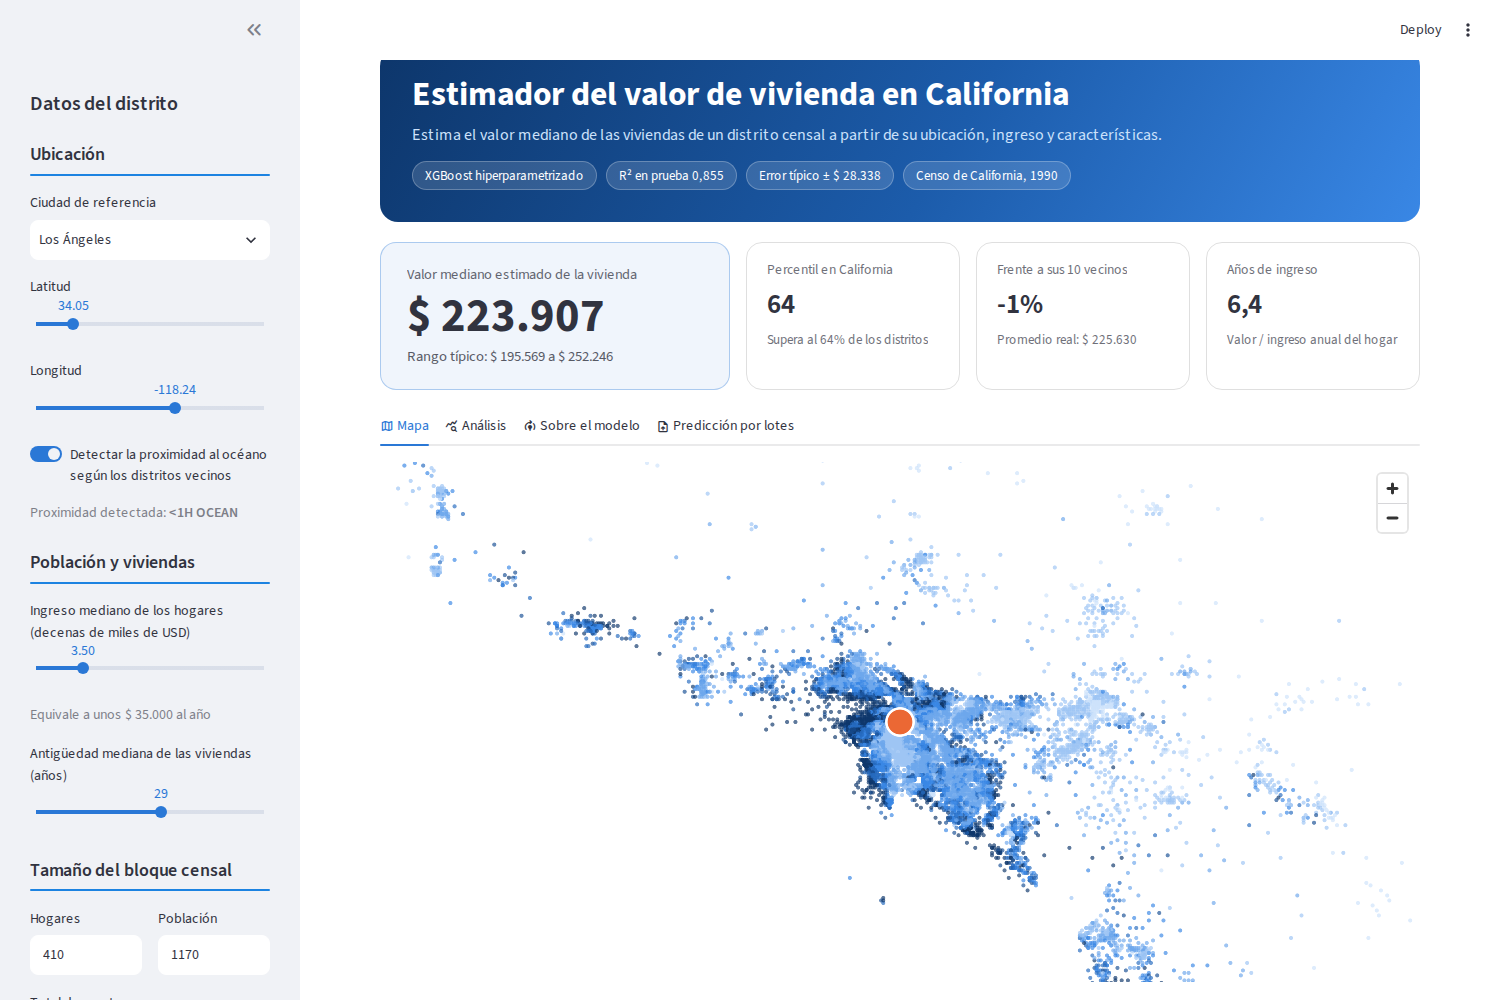